<a href="https://www.kaggle.com/code/lalit7881/product-sales-analysis-eda-100?scriptVersionId=317606353" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jawadaahmed/product-sales-analysis/product_sales_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jawadaahmed/product-sales-analysis/product_sales_dataset.csv")

In [3]:
df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [4]:
df.tail()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
995,1996,Math Guide,Books,266,2,532,2025-11-25,Lahore
996,1997,Keyboard,Electronics,200,5,1000,2026-05-09,Peshawar
997,1998,Face Wash,Beauty,134,4,536,2026-03-27,Islamabad
998,1999,Perfume,Beauty,103,9,927,2026-05-01,Karachi
999,2000,Tennis Ball,Sports,394,2,788,2025-11-30,Peshawar


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Category         1000 non-null   object
 3   Price_USD        1000 non-null   int64 
 4   Quantity_Sold    1000 non-null   int64 
 5   Total_Sales_USD  1000 non-null   int64 
 6   Order_Date       1000 non-null   object
 7   Customer_City    1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [6]:
df.describe()

,Product_ID,Price_USD,Quantity_Sold,Total_Sales_USD
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,253.757000,5.455000,1371.032000
std,288.819436,144.902362,2.964247,1156.021422
min,1001.000000,10.000000,1.000000,10.000000
25%,1250.750000,126.750000,3.000000,425.750000
50%,1500.500000,255.000000,5.000000,1040.000000
75%,1750.250000,383.250000,8.000000,2006.250000
max,2000.000000,500.000000,10.000000,5000.000000


In [7]:
df.isnull().sum()

Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Quantity_Sold',
       'Total_Sales_USD', 'Order_Date', 'Customer_City'],
      dtype='object')

In [10]:
df.nunique()

Product_ID         1000
Product_Name         24
Category              6
Price_USD           413
Quantity_Sold        10
Total_Sales_USD     764
Order_Date          429
Customer_City         5
dtype: int64

In [11]:
df.dtypes

Product_ID          int64
Product_Name       object
Category           object
Price_USD           int64
Quantity_Sold       int64
Total_Sales_USD     int64
Order_Date         object
Customer_City      object
dtype: object

In [12]:
df.shape

(1000, 8)

## EDA

FIRST 5 ROWS
   Product_ID  Product_Name Category  Price_USD  Quantity_Sold  \
0        1001      Lipstick   Beauty         26              7   
1        1002        Jacket  Fashion        254              6   
2        1003    Gym Gloves   Sports         30             10   
3        1004  History Book    Books         45              6   
4        1005   Tennis Ball   Sports        401              1   

   Total_Sales_USD  Order_Date Customer_City  
0              182  2025-01-24       Karachi  
1             1524  2026-04-01      Peshawar  
2              300  2025-11-05      Peshawar  
3              270  2026-01-05        Lahore  
4              401  2025-11-28        Quetta  


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Cat

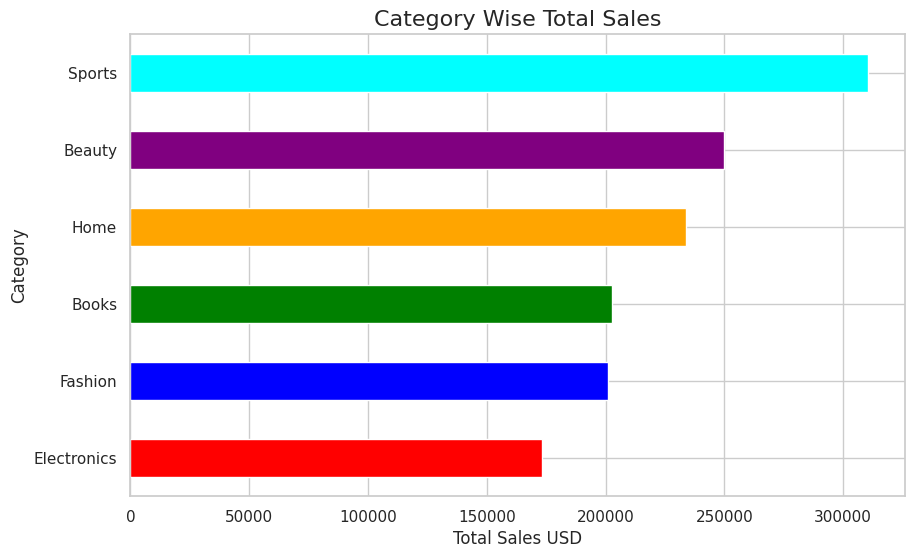

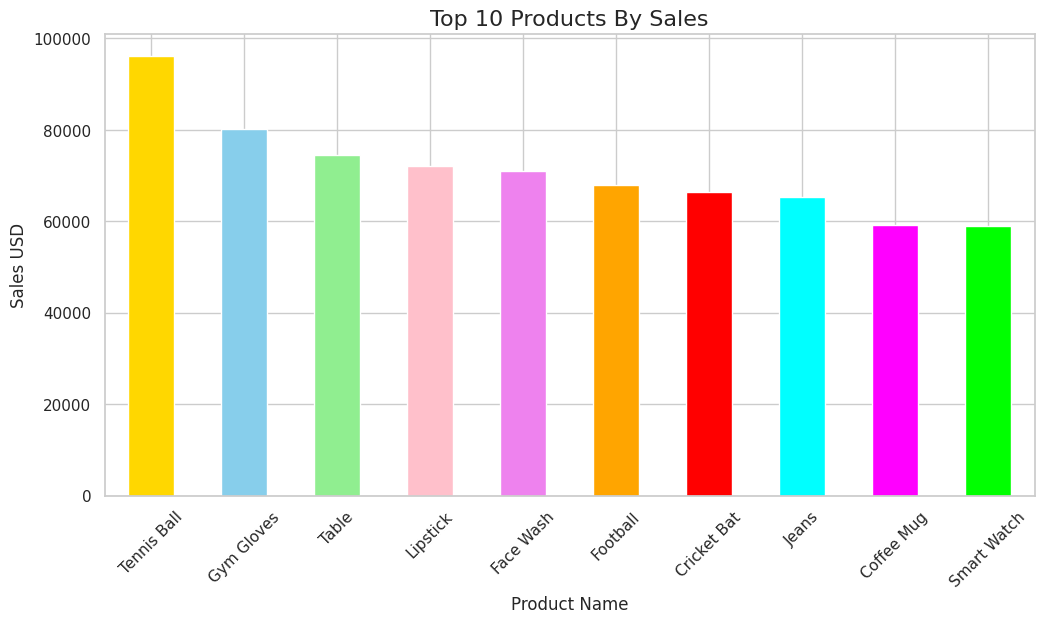

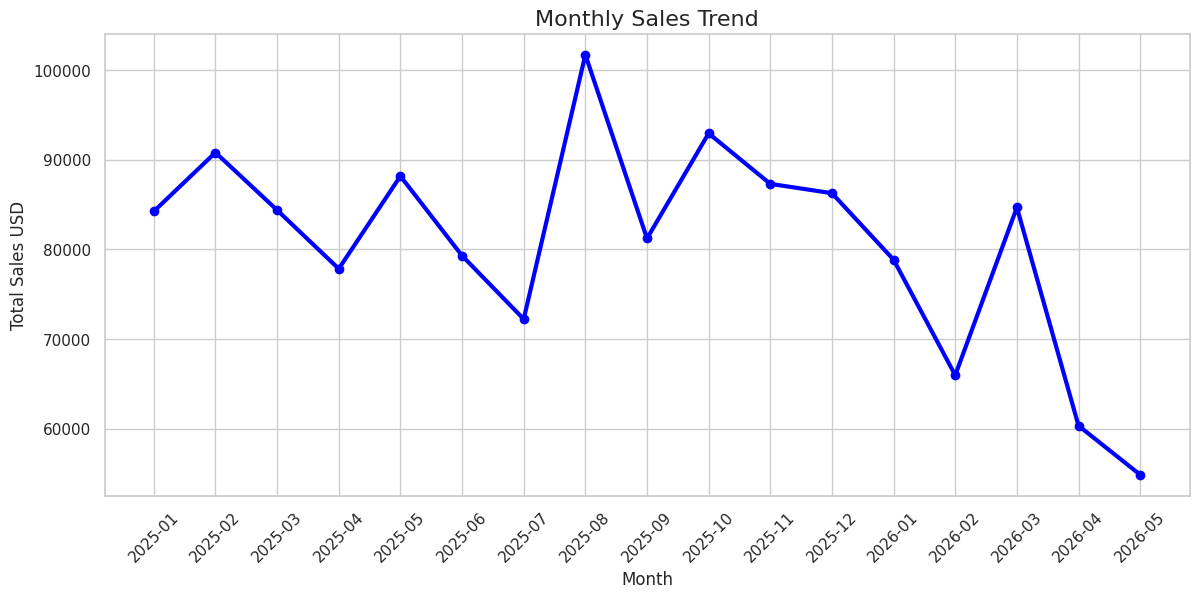

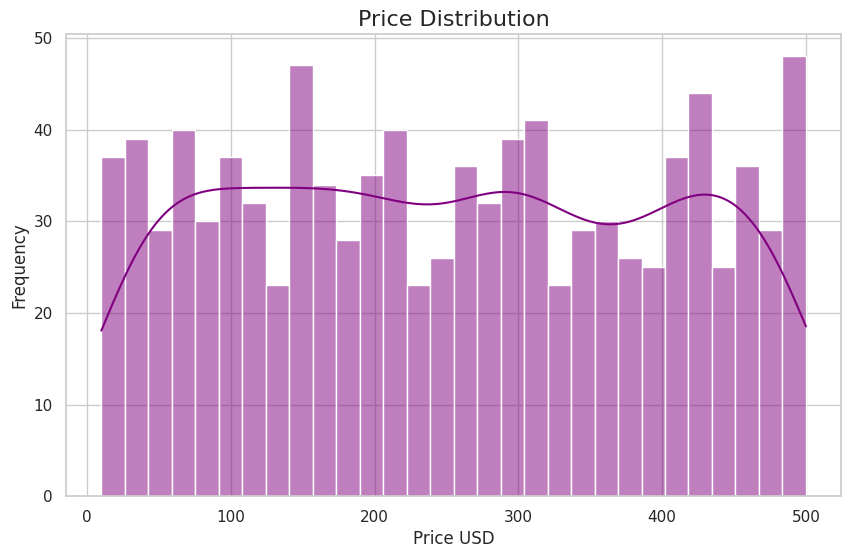

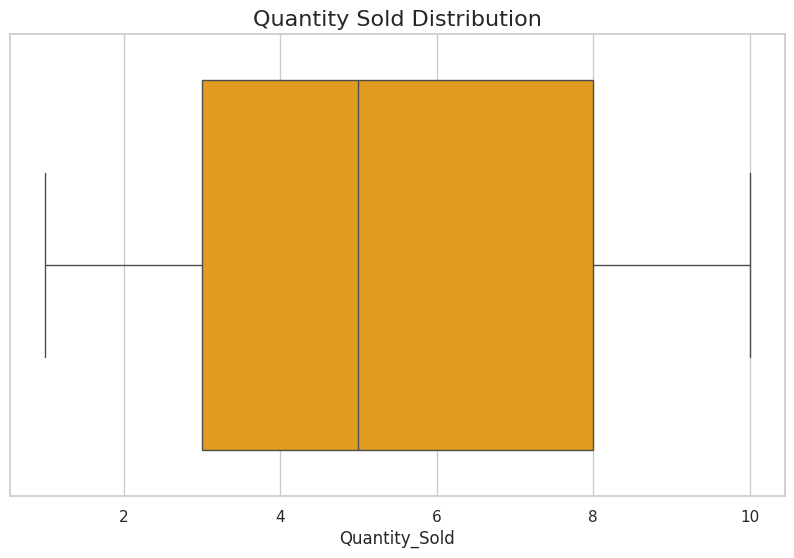

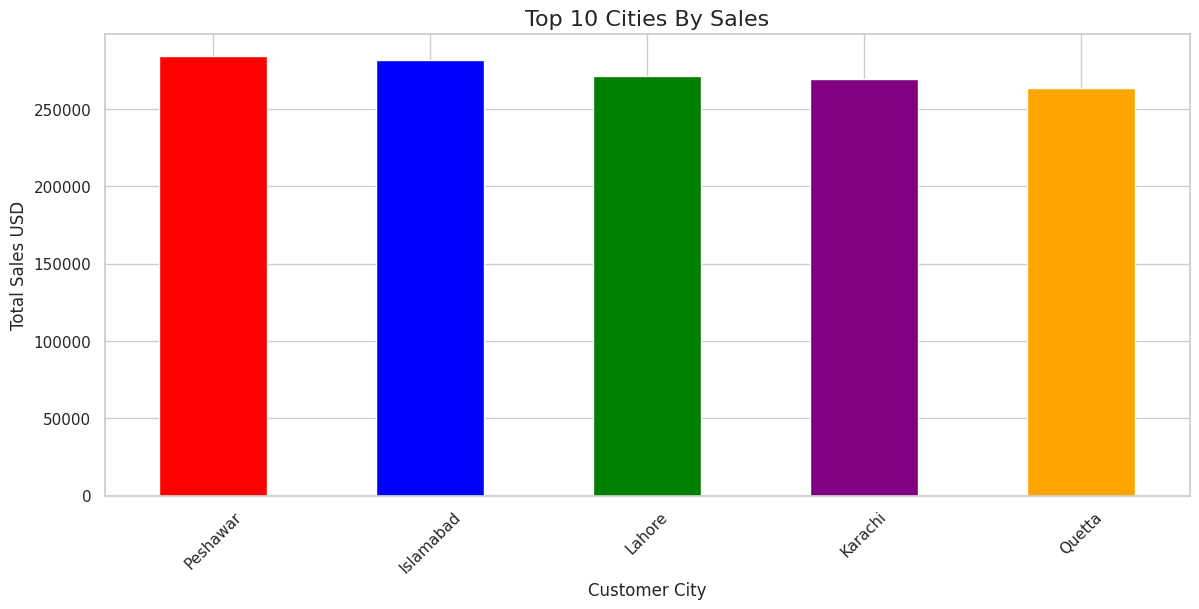

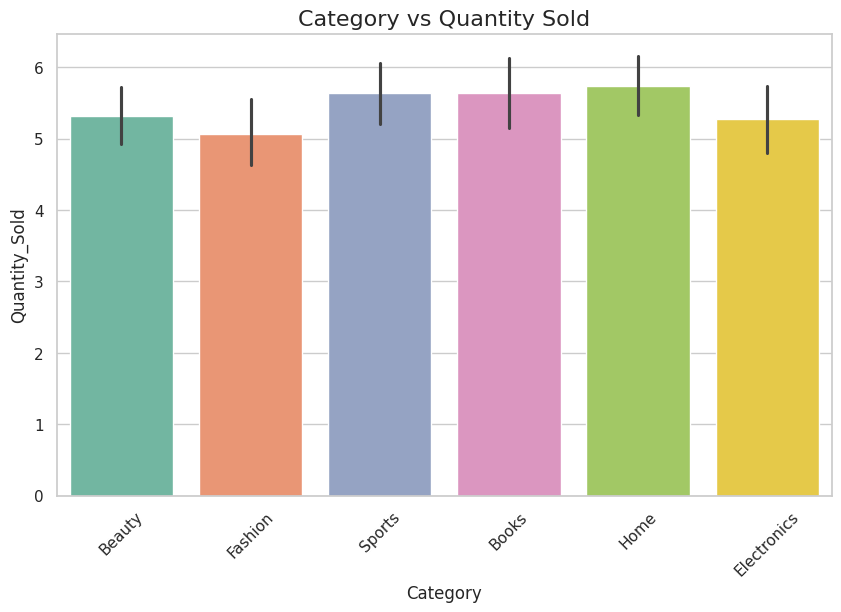

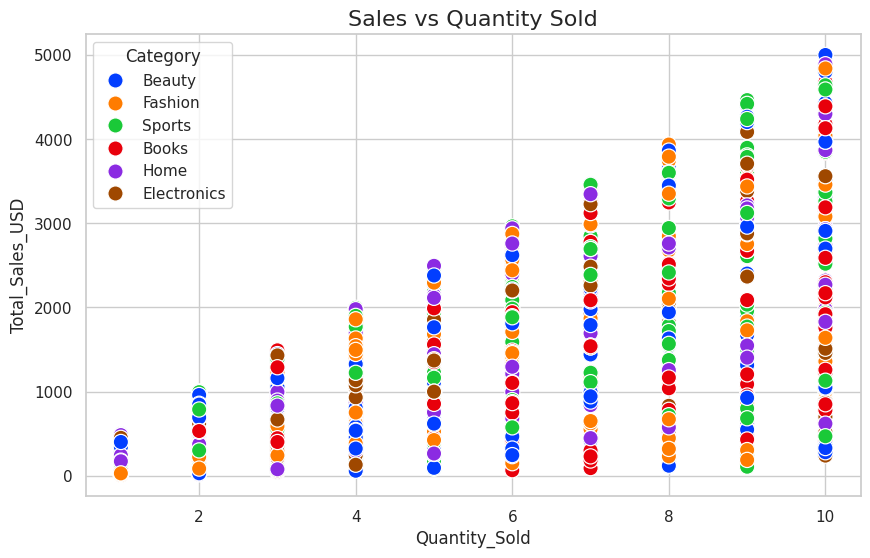

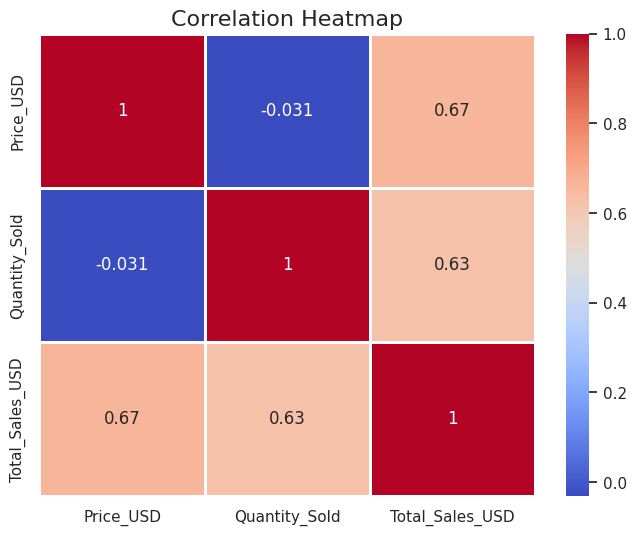

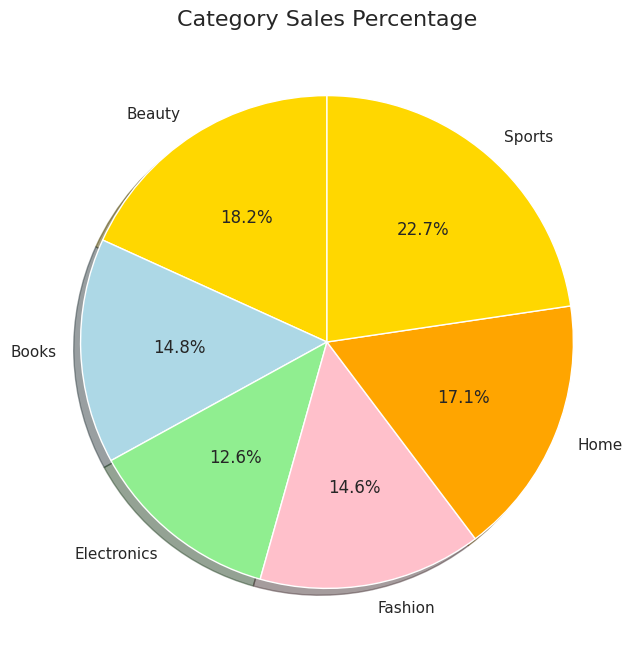

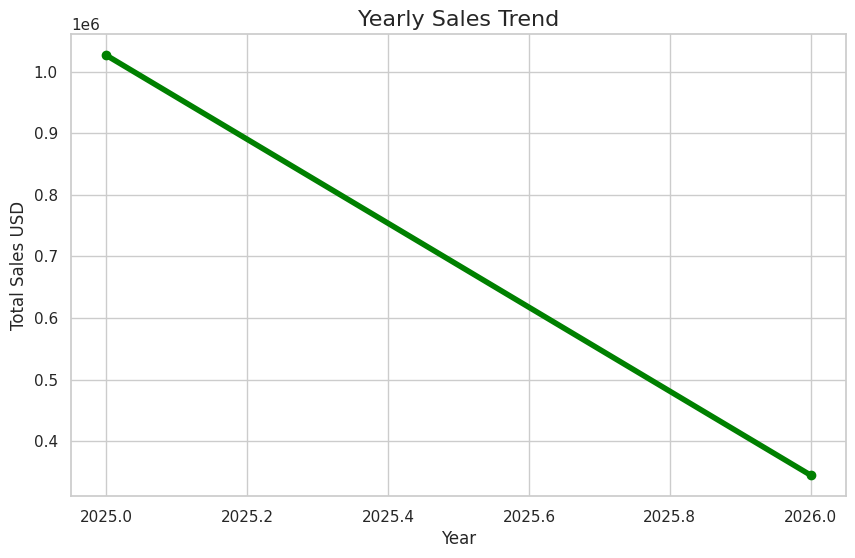

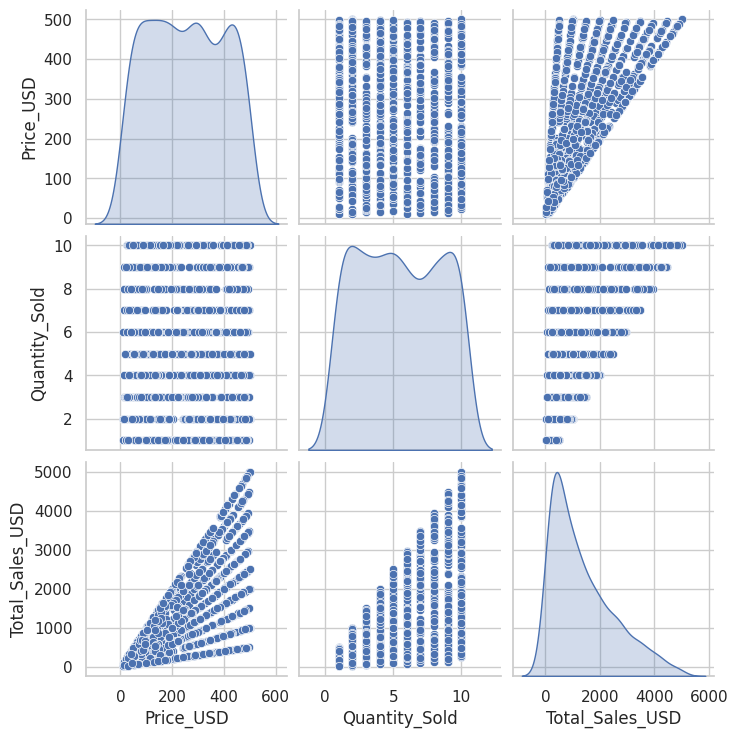

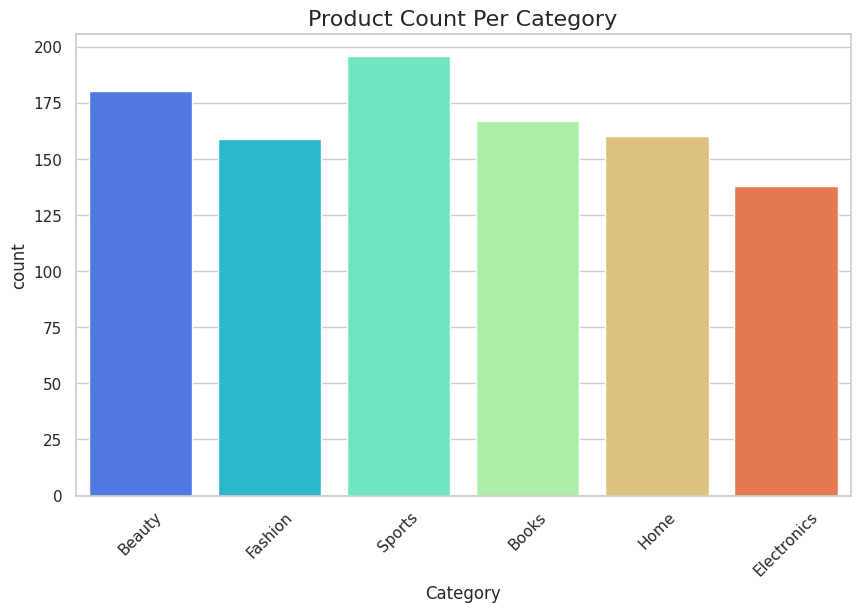

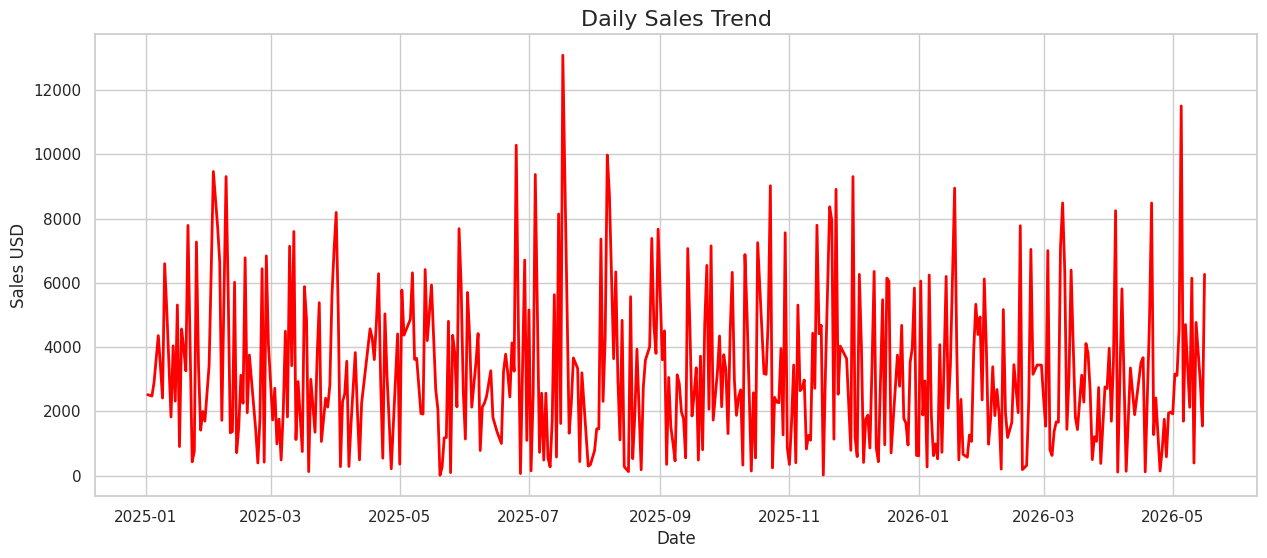

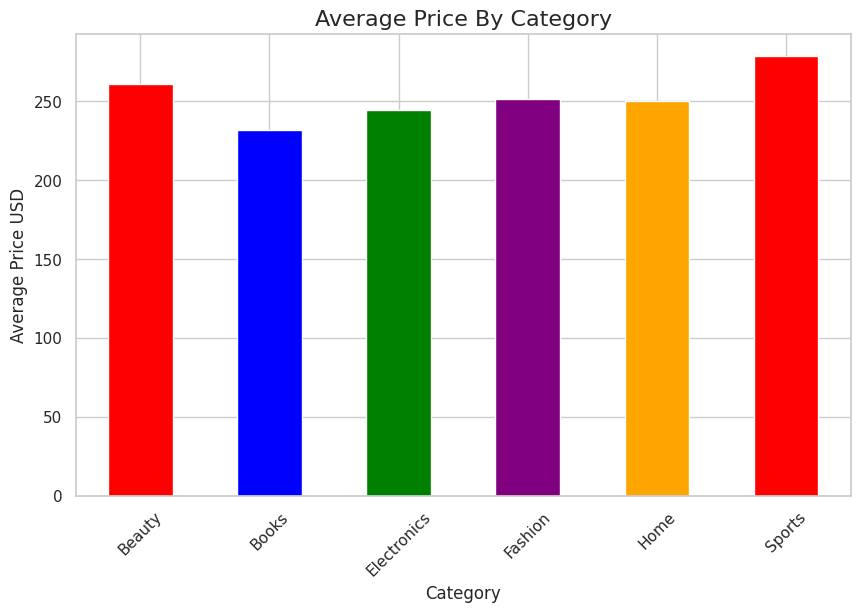

ALL VISUALIZATIONS COMPLETED SUCCESSFULLY


In [13]:
# ================= BASIC INFO =================

print("="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("DATASET INFO")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

# ================= DATE CONVERSION =================

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract Year and Month
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month_name()

# ================= SET STYLE =================

sns.set(style="whitegrid")

# ============================================================
# 1. CATEGORY WISE TOTAL SALES
# ============================================================

plt.figure(figsize=(10,6))

category_sales = df.groupby('Category')['Total_Sales_USD'].sum().sort_values()

colors = ['red','blue','green','orange','purple','cyan','magenta']

category_sales.plot(
    kind='barh',
    color=colors
)

plt.title("Category Wise Total Sales", fontsize=16)
plt.xlabel("Total Sales USD")
plt.ylabel("Category")
plt.show()

# ============================================================
# 2. TOP 10 PRODUCTS BY SALES
# ============================================================

plt.figure(figsize=(12,6))

top_products = df.groupby('Product_Name')['Total_Sales_USD'].sum() \
                 .sort_values(ascending=False).head(10)

colors = ['gold','skyblue','lightgreen','pink','violet',
          'orange','red','cyan','magenta','lime']

top_products.plot(
    kind='bar',
    color=colors
)

plt.title("Top 10 Products By Sales", fontsize=16)
plt.xlabel("Product Name")
plt.ylabel("Sales USD")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 3. MONTHLY SALES TREND
# ============================================================

plt.figure(figsize=(14,6))

monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales_USD'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3,
    color='blue'
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales USD")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ============================================================
# 4. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Price_USD'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Price Distribution", fontsize=16)
plt.xlabel("Price USD")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# 5. QUANTITY SOLD DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Quantity_Sold'],
    color='orange'
)

plt.title("Quantity Sold Distribution", fontsize=16)
plt.show()

# ============================================================
# 6. CITY WISE SALES
# ============================================================

plt.figure(figsize=(14,6))

city_sales = df.groupby('Customer_City')['Total_Sales_USD'].sum() \
               .sort_values(ascending=False).head(10)

colors = ['red','blue','green','purple','orange',
          'cyan','magenta','yellow','lime','pink']

city_sales.plot(
    kind='bar',
    color=colors
)

plt.title("Top 10 Cities By Sales", fontsize=16)
plt.xlabel("Customer City")
plt.ylabel("Total Sales USD")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 7. CATEGORY VS QUANTITY SOLD
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Category',
    y='Quantity_Sold',
    data=df,
    palette='Set2'
)

plt.title("Category vs Quantity Sold", fontsize=16)
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 8. SALES VS QUANTITY SCATTER PLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Quantity_Sold',
    y='Total_Sales_USD',
    hue='Category',
    data=df,
    palette='bright',
    s=120
)

plt.title("Sales vs Quantity Sold", fontsize=16)
plt.show()

# ============================================================
# 9. HEATMAP CORRELATION
# ============================================================

plt.figure(figsize=(8,6))

numeric_df = df[['Price_USD','Quantity_Sold','Total_Sales_USD']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=2
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# ============================================================
# 10. PIE CHART OF CATEGORY SALES
# ============================================================

plt.figure(figsize=(8,8))

category_pie = df.groupby('Category')['Total_Sales_USD'].sum()

colors = ['gold','lightblue','lightgreen','pink','orange']

plt.pie(
    category_pie,
    labels=category_pie.index,
    autopct='%1.1f%%',
    colors=colors,
    shadow=True,
    startangle=90
)

plt.title("Category Sales Percentage", fontsize=16)
plt.show()

# ============================================================
# 11. YEARLY SALES
# ============================================================

plt.figure(figsize=(10,6))

yearly_sales = df.groupby('Year')['Total_Sales_USD'].sum()

yearly_sales.plot(
    kind='line',
    marker='o',
    linewidth=4,
    color='green'
)

plt.title("Yearly Sales Trend", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Sales USD")
plt.grid(True)
plt.show()

# ============================================================
# 12. PAIRPLOT
# ============================================================

sns.pairplot(
    df[['Price_USD','Quantity_Sold','Total_Sales_USD']],
    diag_kind='kde'
)

plt.show()

# ============================================================
# 13. PRODUCT COUNT PER CATEGORY
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Category',
    data=df,
    palette='rainbow'
)

plt.title("Product Count Per Category", fontsize=16)
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 14. DAILY SALES TREND
# ============================================================

daily_sales = df.groupby('Order_Date')['Total_Sales_USD'].sum()

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    color='red',
    linewidth=2
)

plt.title("Daily Sales Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales USD")
plt.grid(True)
plt.show()

# ============================================================
# 15. CATEGORY WISE AVERAGE PRICE
# ============================================================

plt.figure(figsize=(10,6))

avg_price = df.groupby('Category')['Price_USD'].mean()

avg_price.plot(
    kind='bar',
    color=['red','blue','green','purple','orange']
)

plt.title("Average Price By Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Average Price USD")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# END
# ============================================================

print("="*60)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY")
print("="*60)

## Feature engineering

FIRST 5 ROWS
   Product_ID  Product_Name Category  Price_USD  Quantity_Sold  \
0        1001      Lipstick   Beauty         26              7   
1        1002        Jacket  Fashion        254              6   
2        1003    Gym Gloves   Sports         30             10   
3        1004  History Book    Books         45              6   
4        1005   Tennis Ball   Sports        401              1   

   Total_Sales_USD Order_Date Customer_City  Year     Month  
0              182 2025-01-24       Karachi  2025   January  
1             1524 2026-04-01      Peshawar  2026     April  
2              300 2025-11-05      Peshawar  2025  November  
3              270 2026-01-05        Lahore  2026   January  
4              401 2025-11-28        Quetta  2025  November  


DATASET SHAPE
(1000, 10)


MISSING VALUES
Product_ID         0
Product_Name       0
Category           0
Price_USD          0
Quantity_Sold      0
Total_Sales_USD    0
Order_Date         0
Customer_City      0
Year  

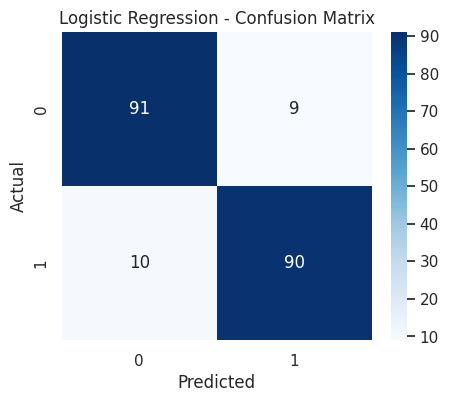

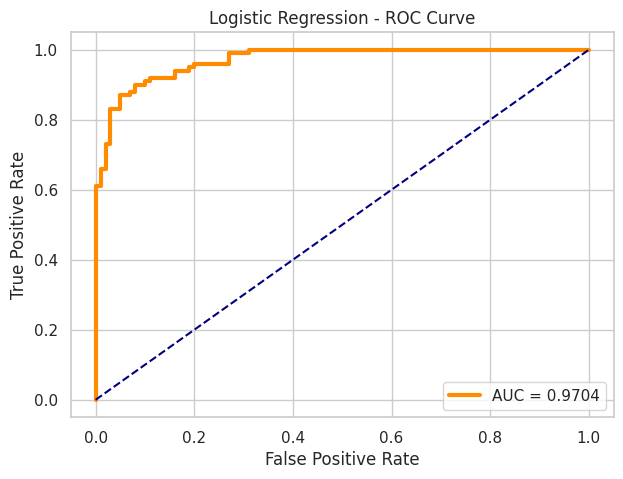



Decision Tree

Accuracy Score : 0.9850
ROC AUC Score  : 0.9850

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.99      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



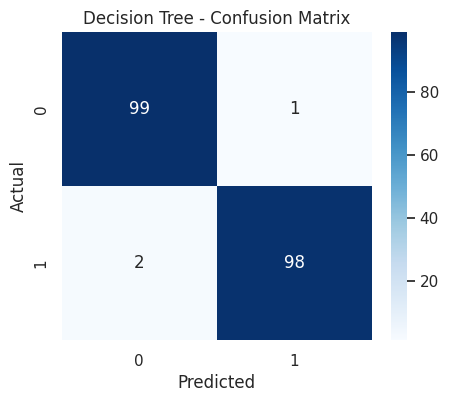

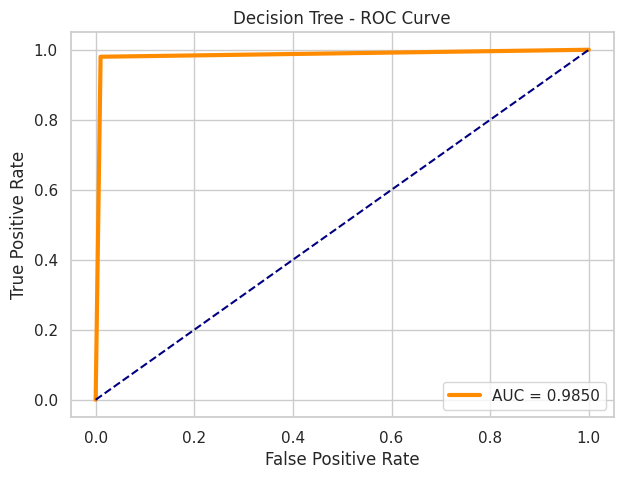



Random Forest

Accuracy Score : 0.9450
ROC AUC Score  : 0.9860

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.95      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



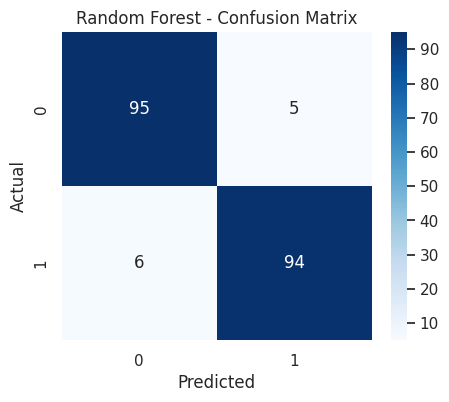

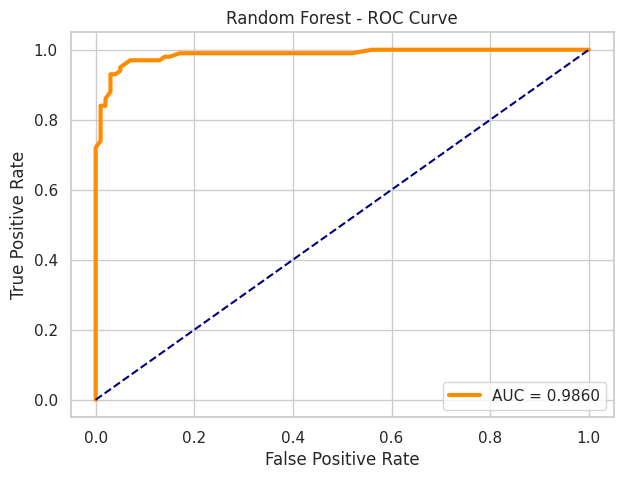



Gradient Boosting

Accuracy Score : 0.9900
ROC AUC Score  : 0.9965

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



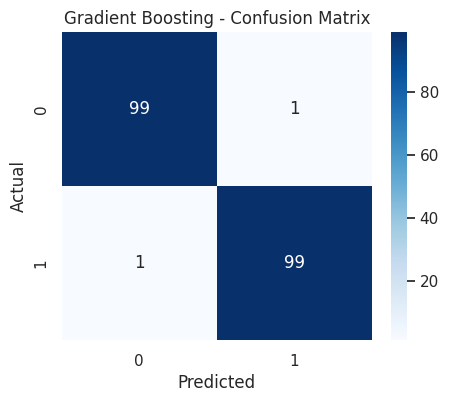

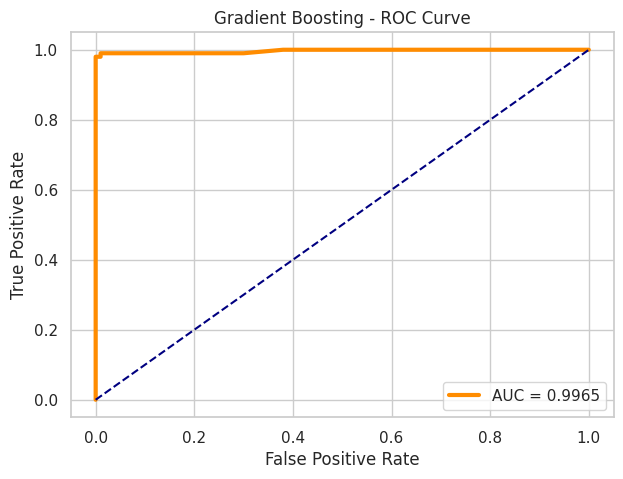



KNN

Accuracy Score : 0.8100
ROC AUC Score  : 0.8831

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.77      0.88      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



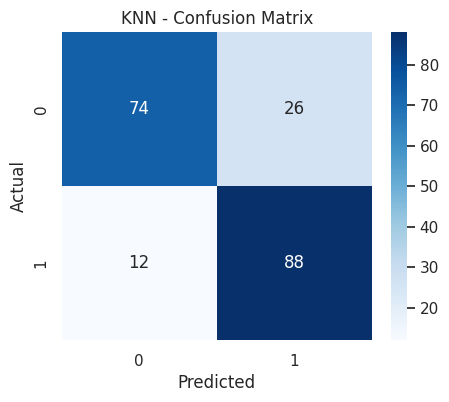

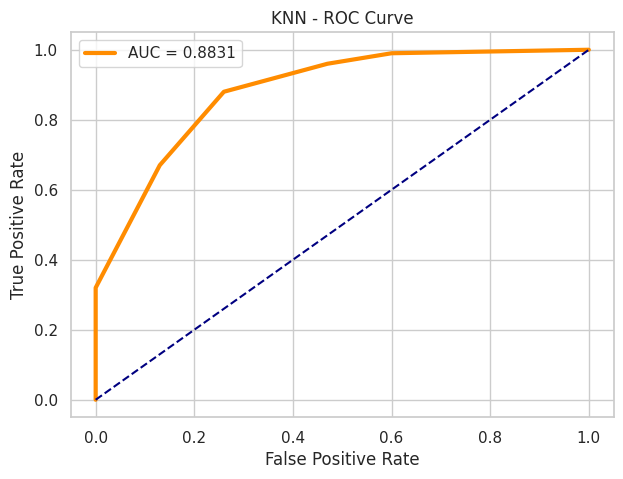



SVM

Accuracy Score : 0.7400
ROC AUC Score  : 0.7961

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       100
           1       0.70      0.83      0.76       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



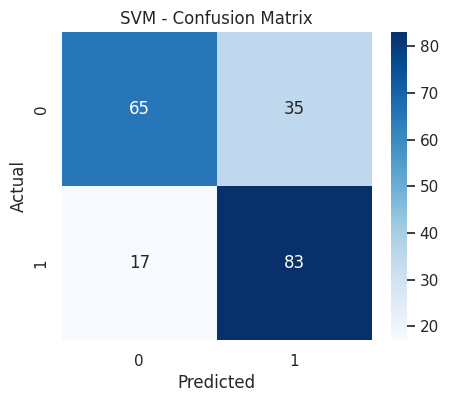

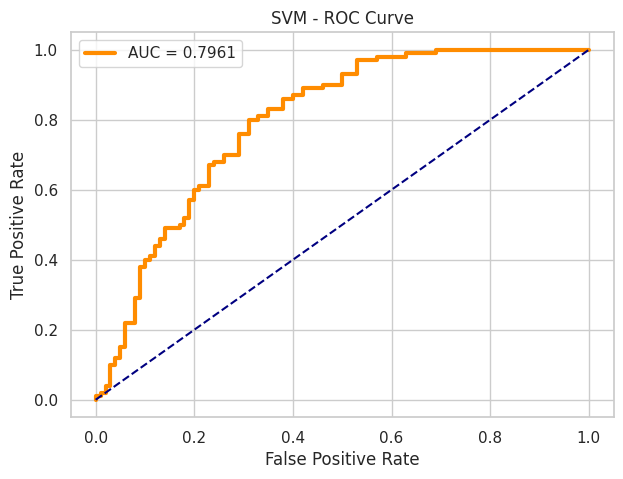



MODEL COMPARISON
                 Model  Accuracy  ROC_AUC
0  Logistic Regression     0.905  0.97040
1        Decision Tree     0.985  0.98500
2        Random Forest     0.945  0.98600
3    Gradient Boosting     0.990  0.99650
4                  KNN     0.810  0.88305
5                  SVM     0.740  0.79610


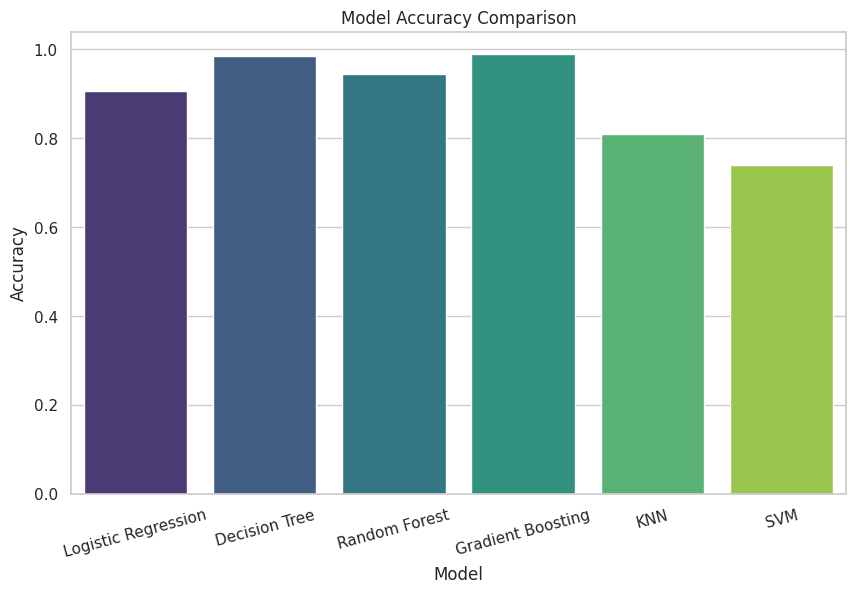



BEST MODEL
Model Name : Gradient Boosting
Accuracy   : 0.9900
ROC AUC    : 0.9965


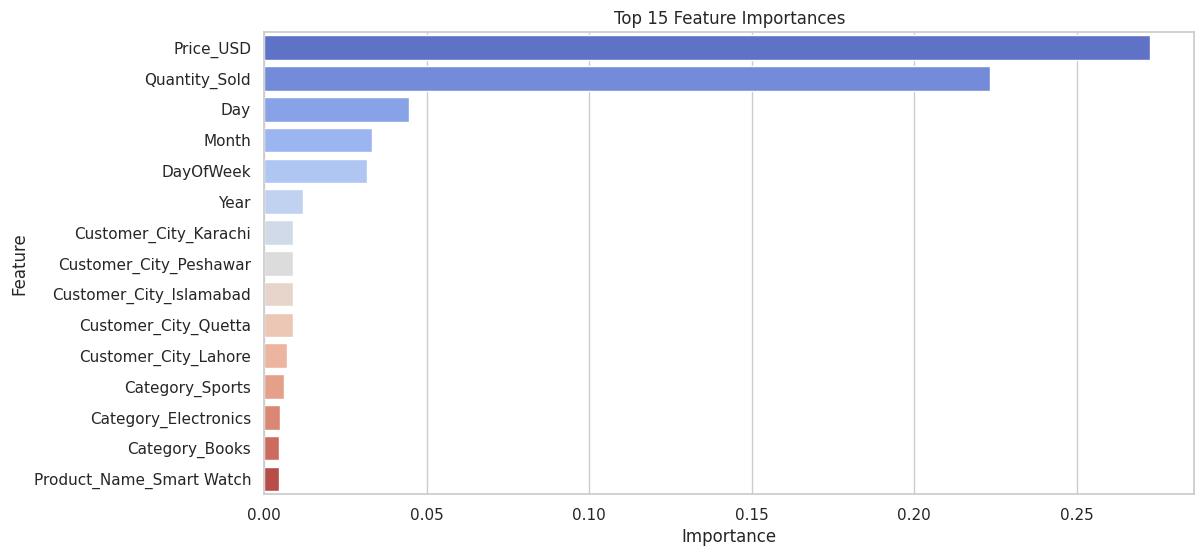



MACHINE LEARNING PROJECT COMPLETED SUCCESSFULLY


In [14]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# ============================================================
# CONVERT DATE COLUMN
# ============================================================

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract Features From Date
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day
df['DayOfWeek'] = df['Order_Date'].dt.dayofweek

# ============================================================
# CREATE TARGET COLUMN
# ============================================================

# High Sales Prediction
# If sales greater than median => 1
# else => 0

median_sales = df['Total_Sales_USD'].median()

df['Target'] = np.where(
    df['Total_Sales_USD'] > median_sales,
    1,
    0
)

print("\n")

print("="*60)
print("TARGET VALUE COUNTS")
print("="*60)
print(df['Target'].value_counts())

# ============================================================
# DROP LEAKAGE COLUMNS
# ============================================================

# IMPORTANT:
# Total_Sales_USD directly creates target
# So remove it to avoid DATA LEAKAGE

X = df.drop(columns=[
    'Target',
    'Total_Sales_USD',
    'Order_Date'
])

y = df['Target']

# ============================================================
# FEATURE COLUMNS
# ============================================================

categorical_cols = [
    'Product_ID',
    'Product_Name',
    'Category',
    'Customer_City'
]

numeric_cols = [
    'Price_USD',
    'Quantity_Sold',
    'Year',
    'Month',
    'Day',
    'DayOfWeek'
]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n")

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

# ============================================================
# TRAINING AND EVALUATION
# ============================================================

results = []

for name, model in models.items():

    print("\n")
    print("="*70)
    print(f"{name}")
    print("="*70)

    # Create Full Pipeline
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train Model
    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)

    # Probability Predictions
    y_prob = clf.predict_proba(X_test)[:,1]

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # ROC AUC SCORE
    # ========================================================

    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"ROC AUC Score  : {roc_auc:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report")
    print("-"*50)

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(7,5))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC = {roc_auc:.4f}',
        linewidth=3,
        color='darkorange'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--',
        color='navy'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.show()

    # Save Results
    results.append([name, accuracy, roc_auc])

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'ROC_AUC']
)

print("\n")

print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

# ============================================================
# VISUALIZE MODEL PERFORMANCE
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")

print("="*70)
print("BEST MODEL")
print("="*70)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

# Extract feature names
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
].get_feature_names_out(categorical_cols)

all_features = numeric_cols + list(encoded_cat_features)

# Feature Importance
importances = rf_pipeline.named_steps[
    'classifier'
].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot Feature Importance
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 15 Feature Importances")
plt.show()

# ============================================================
# END
# ============================================================

print("\n")
print("="*70)
print("MACHINE LEARNING PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

## Thank you...pls upvote!!!!!!!